# Test the statistical method for different scenario

In [21]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'a':'#941717', 'b':'#388E3C','c':'#42A5F5', 'd':'#FFA000', 's':'k'}

In [27]:
def build_dataset(a, b, c, d, row):
    ds = xr.Dataset(
        data_vars=dict(
            a=("row", a),
            b=("row", b),
            c=("row", c),
            d=("row", d),
        ), 
        coords=dict(row=("row", row)
                   )
    )
    
    ds['s'] = ds.a + ds.b + ds.c +ds.d
    ds['exca'] = ds.b + ds.c + ds.d
    ds['excb'] = ds.a + ds.c + ds.d
    ds['excc'] = ds.a + ds.b + ds.d
    ds['excd'] = ds.a + ds.b + ds.c
    
    ds['Xab'] = -2*ds.a*ds.b
    ds['Xbc'] = -2*ds.b*ds.c
    ds['Xac'] = -2*ds.a*ds.c
    ds['Xad'] = -2*ds.a*ds.d
    ds['Xbd'] = -2*ds.b*ds.d
    ds['Xcd'] = -2*ds.c*ds.d
    
    ds['Ea'] = a*ds.s
    ds['Eb'] = b*ds.s
    ds['Ec'] = c*ds.s
    ds['Ed'] = d*ds.s
    
    
    ds['Ba'] = -a*ds.exca
    ds['Bb'] = -b*ds.excb
    ds['Bc'] = -c*ds.excc
    ds['Bd'] = -d*ds.excd
    
    return ds

def plot_terms(ds):
    fig, axs = plt.subplots(1, 5, sharey=True, frameon=False, figsize=(10,3))
    i=0
    for var in ['a', 'b','c','d', 's']:
        ds[var].plot(ax=axs[i], color = c0[var])
        i+=1
    for ax in axs :
        ax.grid()

def stats_mean_dataset(ds) :
    var2 = ['a', 'b', 'c', 'd', 's']
    ds2 = ds[[v for v in ds if v not in var2]].mean(dim='row')
    ds2 = xr.merge([ds2, (ds**2)[var2].mean(dim='row')])
    return ds2
    

__________________________
# 1. First case : Mean =0; 4 uncorrelated terms - no errors

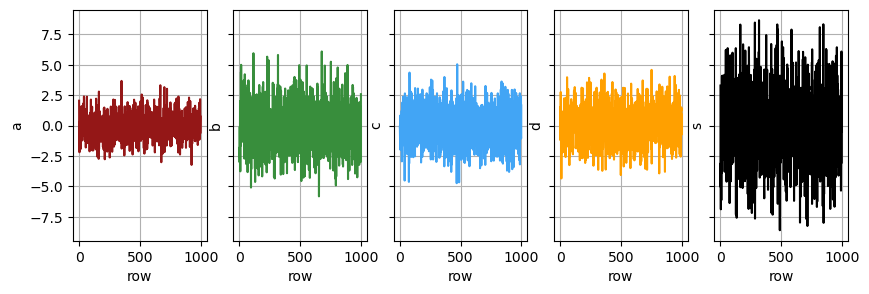

In [30]:
N=1000 # nb coloc
std = [1, 2, 1.5, 1]
mean = [0,0,0,0]
row = np.arange(0, N)

a = np.random.normal(0, std[0], N)
b = np.random.normal(0, std[1], N)
c = np.random.normal(0, std[2], N)
d = np.random.normal(0, std[2], N)

ds = build_dataset(a, b, c, d, row)
plot_terms(ds)

In [32]:
ds2 = stats_mean_dataset(ds)

# 4 terms

In [172]:
siga = 1
sigb = 2
sigab = 1.5
N=10000

comab = np.random.normal(0.1, sigab, N)
a = np.random.normal(1.8, siga, N)+comab
b = np.random.normal(2, sigb, N)-comab
c = -a-b

row = np.arange(0, N)

ds = xr.Dataset(
    data_vars=dict(
        a=("row", a),
        b=("row", b),
        c=("row", c),
    ), 
    coords=dict(row=("row", row)
               )
)
ds['s'] = ds.a + ds.b + ds.c
ds['exca'] = ds.b + ds.c
ds['excb'] = ds.a + ds.c
ds['excc'] = ds.a + ds.b

ds['Xab'] = -2*ds.a*ds.b
ds['Xbc'] = -2*ds.b*ds.c
ds['Xac'] = -2*ds.a*ds.c

ds['Ea'] = a*ds.s
ds['Eb'] = b*ds.s
ds['Ec'] = c*ds.s

ds['Ba'] = -a*ds.exca
ds['Bb'] = -b*ds.excb
ds['Bc'] = -c*ds.excc

v2 = ['a', 'b', 'c', 's', 'exca', 'excb', 'excc']

dm2 = (ds[v2]**2)
dm = ds[[v for v in ds if v not in v2]]

dm = xr.merge([dm, dm2]).mean('row')

In [173]:
dm

<xarray.Dataset> Size: 128B
Dimensions:  ()
Data variables: (12/16)
    Xab      float64 8B -2.738
    Xbc      float64 8B 22.28
    Xac      float64 8B 16.63
    Ea       float64 8B 0.0
    Eb       float64 8B 0.0
    Ec       float64 8B 0.0
    ...       ...
    b        float64 8B 9.769
    c        float64 8B 19.45
    s        float64 8B 0.0
    exca     float64 8B 6.944
    excb     float64 8B 9.769
    excc     float64 8B 19.45

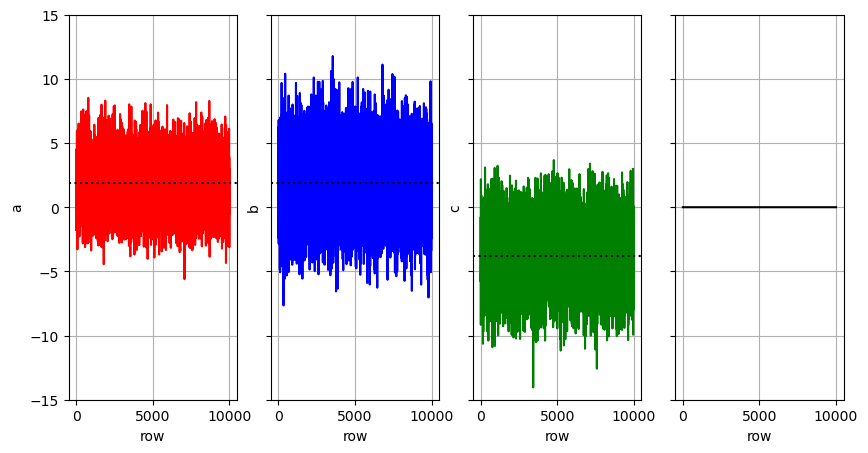

In [193]:
fig, axs =plt.subplots(1,4, sharey=True, figsize = (10, 5))
ds.a.plot(c='r', ax=axs[0])
axs[0].axhline(ds.a.mean('row'), c='k', ls=':')
ds.b.plot(c='b', ax=axs[1])
axs[1].axhline(ds.b.mean('row'), c='k', ls=':')
ds.c.plot(c='g', ax=axs[2])
axs[2].axhline(ds.c.mean('row'), c='k', ls=':')
(ds.a+ds.b+ds.c).plot(c='k', ax=axs[3])

for ax in axs:
    ax.grid()
    ax.set_ylim(-15, 15)

In [175]:
dm

<xarray.Dataset> Size: 128B
Dimensions:  ()
Data variables: (12/16)
    Xab      float64 8B -2.738
    Xbc      float64 8B 22.28
    Xac      float64 8B 16.63
    Ea       float64 8B 0.0
    Eb       float64 8B 0.0
    Ec       float64 8B 0.0
    ...       ...
    b        float64 8B 9.769
    c        float64 8B 19.45
    s        float64 8B 0.0
    exca     float64 8B 6.944
    excb     float64 8B 9.769
    excc     float64 8B 19.45

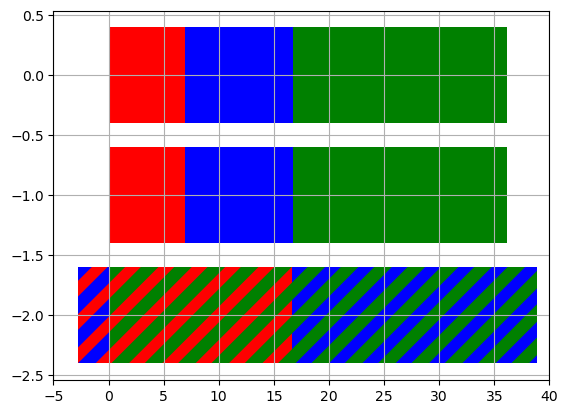

In [181]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dm.a, color='r')
ax.barh(0, dm.b, left=dm.a, color='b')
ax.barh(0, dm.c, left=dm.b+dm.a, color='g')

ax.barh(-1, dm.Ba, color='r')
ax.barh(-1, dm.Ea, left=dm.Ba, color='grey')
ax.barh(-1, dm.Bb, left=dm.Ba +dm.Ea, color='b')
ax.barh(-1, dm.Eb, left=dm.Ba +dm.Ea+dm.Bb, color='grey')
ax.barh(-1, dm.Bc, left=dm.Ba +dm.Ea+dm.Bb+dm.Eb, color='g')
ax.barh(-1, dm.Ec, left=dm.Ba +dm.Ea+dm.Bb+dm.Eb+dm.Bc, color='grey')

plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'r'
ax.barh(-2, dm.Xab, color='b', hatch = '/')
ax.barh(-2, dm.Xac,left = max(0, dm.Xab), color='g', hatch = '/')
plt.rcParams["hatch.color"] = 'b'
ax.barh(-2, dm.Xbc,left =max(0,dm.Xab)+max(dm.Xac,0),  color='g', hatch = '/')

ax.set_xlim(-5, 40)
ax.grid()

In [179]:
dsa  = ds[['b', 'c']]
dsa['s'] =  dsa.b + dsa.c
dsa['excb'] = dsa.c
dsa['excc'] = dsa.b

dsa['Xbc'] = -2*dsa.b*dsa.c

dsa['Eb'] = b*dsa.s
dsa['Ec'] = c*dsa.s

dsa['Bb'] = -b*dsa.excb
dsa['Bc'] = -c*dsa.excc

v2 = [ 'b', 'c', 's', 'excb', 'excc']

dm2a = (dsa[v2]**2)
dma = dsa[[v for v in dsa if v not in v2]]

dma = xr.merge([dma, dm2a]).mean('row')

In [159]:
dma

<xarray.Dataset> Size: 80B
Dimensions:  ()
Data variables:
    Xbc      float64 8B 12.23
    Eb       float64 8B 4.586
    Ec       float64 8B -0.03604
    Bb       float64 8B 6.117
    Bc       float64 8B 6.117
    b        float64 8B 10.7
    c        float64 8B 6.081
    s        float64 8B 4.55
    excb     float64 8B 6.081
    excc     float64 8B 10.7

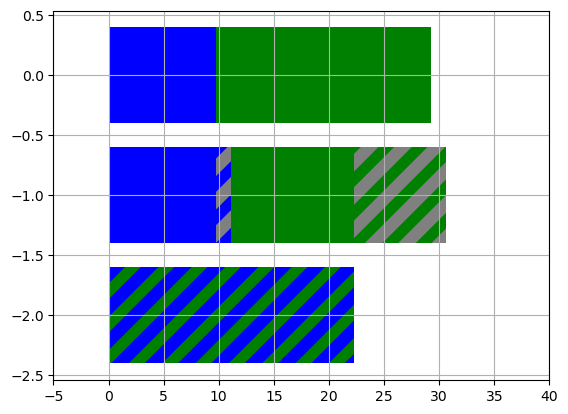

In [182]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dma.b, color='b')
ax.barh(0, dma.c, left=dma.b, color='g')


ax.barh(-1, dma.Bb, color='b')
plt.rcParams["hatch.color"] = 'b'
ax.barh(-1, dma.Eb,left=max(0,dma.Bb), color='grey', hatch='/')
ax.barh(-1, dma.Bc, left=max(0,dma.Bb)+max(0,dma.Eb), color='g')
plt.rcParams["hatch.color"] = 'g'
ax.barh(-1, dma.Ec, left = max(0,dma.Bb) + max(0,dma.Eb) + max(dma.Bc,0), color='grey', hatch='/')

plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'g'
ax.barh(-2, dma.Xbc, color='b', hatch = '/')
ax.set_xlim(-5, 40)
ax.grid()

In [184]:
dsc  = ds[['a', 'b']]
dsc['s'] =  dsc.a + dsc.b
dsc['exca'] = dsc.b
dsc['excb'] = dsc.a

dsc['Xab'] = -2*dsc.a*dsc.b

dsc['Ea'] = a*dsc.s
dsc['Eb'] = b*dsc.s

dsc['Ba'] = -a*dsc.exca
dsc['Bb'] = -b*dsc.excb

v2 = [ 'a', 'b', 's', 'exca', 'excb']

dm2c = (dsc[v2]**2)
dmc = dsc[[v for v in dsc if v not in v2]]

dmc = xr.merge([dmc, dm2c]).mean('row')

In [185]:
dmc

<xarray.Dataset> Size: 80B
Dimensions:  ()
Data variables:
    Xab      float64 8B -2.738
    Ea       float64 8B 8.313
    Eb       float64 8B 11.14
    Ba       float64 8B -1.369
    Bb       float64 8B -1.369
    a        float64 8B 6.944
    b        float64 8B 9.769
    s        float64 8B 19.45
    exca     float64 8B 9.769
    excb     float64 8B 6.944

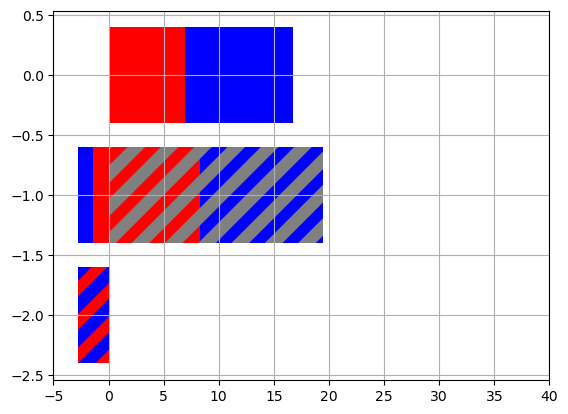

In [191]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dmc.a, color='r')
ax.barh(0, dmc.b, left=dmc.a, color='b')

ax.barh(-1, dmc.Ba, color='r')
plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'r'
ax.barh(-1, dmc.Ea, left=max(0, dmc.Ba), color='grey', hatch='/')
ax.barh(-1, dmc.Bb, left=dmc.Ba, color='b')
plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'b'
ax.barh(-1, dmc.Eb, left=max(0,dmc.Ba)+max(0,dmc.Bb)+ dmc.Ea, color='grey', hatch='/')


plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'r'
ax.barh(-2, dmc.Xab, color='b', hatch = '/')

ax.set_xlim(-5, 40)
ax.grid()